# Notebook 02 — EDA & Visualization
**Unit V: Data Analytics and Visualization**

Covers:
- Team win percentages
- Toss impact on match result
- Top run scorers & wicket takers
- Venue analysis
- Season trends (2008–2024)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load cleaned CSV
df = pd.read_csv('../data/ipl_clean.csv')
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print('\nColumn names:')
print(df.columns.tolist())

Loaded: 283,678 rows, 65 columns

Column names:
['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'power_surge_start', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']


---
## 2.1 Team Win Percentage

> **Note:** If your CSV has match-level data (one row = one match), use the block below directly.  
> If it has delivery-level data (one row = one ball), uncomment the aggregation block first.

In [3]:
# ── OPTION A: match-level CSV (columns: 'team1', 'team2', 'winner') ───────────
# Change column names to match YOUR csv

if 'winner' in df.columns and 'team1' in df.columns:
    # Count matches played
    teams_played = pd.concat([df['team1'], df['team2']]).value_counts().reset_index()
    teams_played.columns = ['team', 'played']

    # Count wins
    wins = df['winner'].value_counts().reset_index()
    wins.columns = ['team', 'wins']

    win_pct = teams_played.merge(wins, on='team', how='left')
    win_pct['wins'] = win_pct['wins'].fillna(0)
    win_pct['win_pct'] = (win_pct['wins'] / win_pct['played'] * 100).round(1)
    win_pct = win_pct[win_pct['played'] >= 10].sort_values('win_pct', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    colors = sns.color_palette('RdYlGn', len(win_pct))
    bars = ax.barh(win_pct['team'], win_pct['win_pct'], color=colors)
    ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
    ax.set_xlabel('Win Percentage (%)')
    ax.set_title('IPL Team Win Percentage (min. 10 matches)')
    ax.set_xlim(0, 80)
    plt.tight_layout()
    plt.savefig('../data/plot_win_pct.png', bbox_inches='tight')
    plt.show()
    print(win_pct.to_string(index=False))
else:
    print('Column "winner" or "team1" not found. Check your column names.')

Column "winner" or "team1" not found. Check your column names.


## 2.2 Toss Impact on Match Outcome

In [4]:
# Expects columns: 'toss_winner', 'winner', 'toss_decision'
if 'toss_winner' in df.columns and 'winner' in df.columns:
    df['toss_match_winner'] = df['toss_winner'] == df['winner']

    toss_effect = df.groupby('toss_decision')['toss_match_winner'].mean().reset_index()
    toss_effect.columns = ['Decision', 'Win Rate']
    toss_effect['Win Rate'] = (toss_effect['Win Rate'] * 100).round(1)

    overall_toss_win = df['toss_match_winner'].mean() * 100

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Pie: toss winner also won match
    won = df['toss_match_winner'].sum()
    lost = len(df) - won
    axes[0].pie([won, lost], labels=['Won Match', 'Lost Match'],
                autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
                startangle=90, wedgeprops={'edgecolor': 'white'})
    axes[0].set_title(f'Toss winner wins the match\n(Overall: {overall_toss_win:.1f}%)')

    # Bar: by decision
    sns.barplot(data=toss_effect, x='Decision', y='Win Rate',
                palette=['#3498db', '#e67e22'], ax=axes[1])
    axes[1].set_title('Win Rate by Toss Decision')
    axes[1].set_ylabel('Win Rate (%)')
    axes[1].set_ylim(0, 80)
    for p in axes[1].patches:
        axes[1].annotate(f'{p.get_height():.1f}%',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=11)
    plt.tight_layout()
    plt.savefig('../data/plot_toss.png', bbox_inches='tight')
    plt.show()
    print(toss_effect)
else:
    print('Columns toss_winner / winner not found. Check column names.')

Columns toss_winner / winner not found. Check column names.


## 2.3 Top Run Scorers

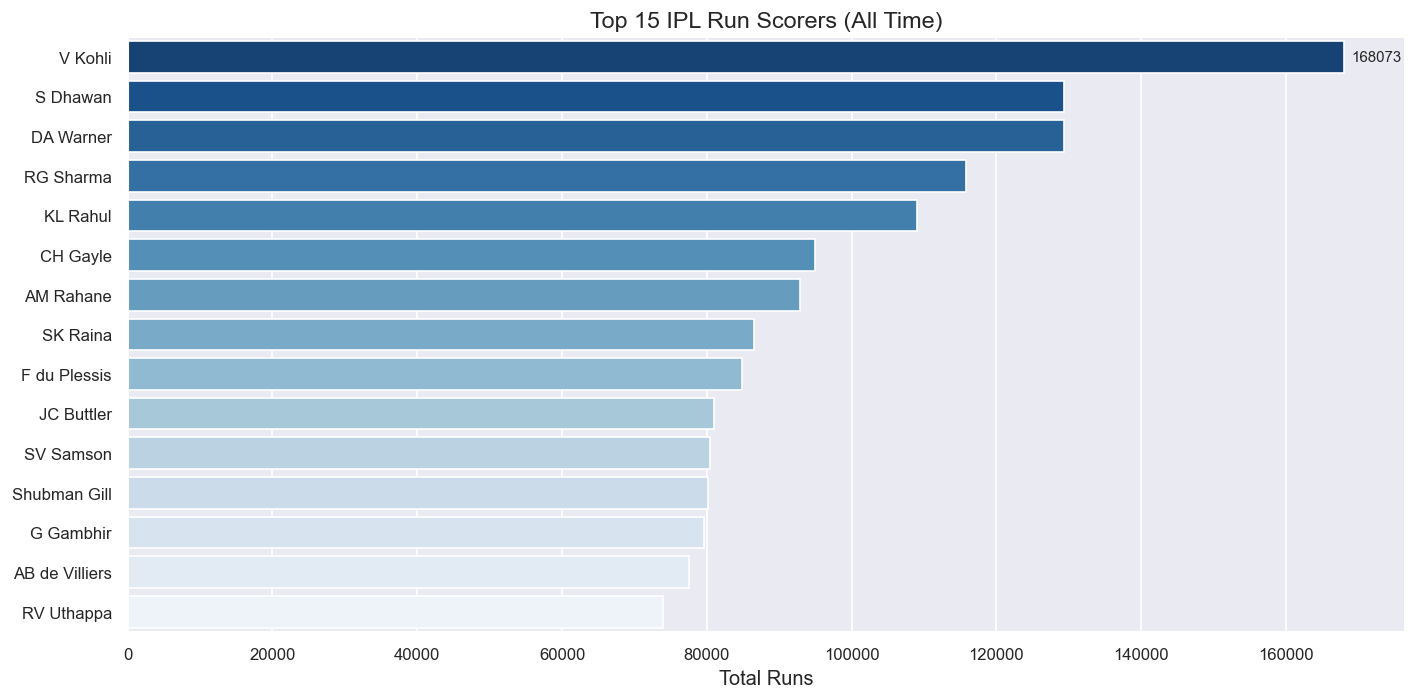

        Player  Total Runs
       V Kohli      168073
      S Dhawan      129391
     DA Warner      129387
     RG Sharma      115874
      KL Rahul      108994
      CH Gayle       95007
     AM Rahane       92877
      SK Raina       86545
  F du Plessis       84811
    JC Buttler       80929
     SV Samson       80459
  Shubman Gill       80207
     G Gambhir       79674
AB de Villiers       77589
    RV Uthappa       73994


In [5]:
# Expects columns: 'batter' (or 'batsman') and 'batsman_runs' (or 'batter_runs')

# Auto-detect column names
batter_col = 'batter' if 'batter' in df.columns else 'batsman'
runs_col   = 'batter_runs' if 'batter_runs' in df.columns else 'batsman_runs'

if batter_col in df.columns and runs_col in df.columns:
    top_scorers = (df.groupby(batter_col)[runs_col]
                     .sum()
                     .sort_values(ascending=False)
                     .head(15)
                     .reset_index())
    top_scorers.columns = ['Player', 'Total Runs']

    fig, ax = plt.subplots(figsize=(12, 6))
    palette = sns.color_palette('Blues_r', len(top_scorers))
    bars = sns.barplot(data=top_scorers, y='Player', x='Total Runs',
                       palette=palette, ax=ax)
    ax.bar_label(ax.containers[0], fmt='%d', padding=4, fontsize=9)
    ax.set_title('Top 15 IPL Run Scorers (All Time)')
    ax.set_xlabel('Total Runs')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('../data/plot_top_scorers.png', bbox_inches='tight')
    plt.show()
    print(top_scorers.to_string(index=False))
else:
    print(f'Column "{batter_col}" or "{runs_col}" not found.')

## 2.4 Top Wicket Takers

In [6]:
# Expects columns: 'bowler', 'player_dismissed' or 'is_wicket'
bowler_col = 'bowler' if 'bowler' in df.columns else None
wicket_col = None
if 'is_wicket' in df.columns:
    wicket_col = 'is_wicket'
elif 'player_dismissed' in df.columns:
    # Create binary wicket column
    df['is_wicket'] = df['player_dismissed'].apply(
        lambda x: 0 if (pd.isna(x) or x in ['Unknown', '', 'nan']) else 1
    )
    wicket_col = 'is_wicket'

if bowler_col and wicket_col:
    top_wickets = (df[df[wicket_col] == 1]
                     .groupby(bowler_col)[wicket_col]
                     .sum()
                     .sort_values(ascending=False)
                     .head(15)
                     .reset_index())
    top_wickets.columns = ['Bowler', 'Wickets']

    fig, ax = plt.subplots(figsize=(12, 6))
    palette = sns.color_palette('Reds_r', len(top_wickets))
    sns.barplot(data=top_wickets, y='Bowler', x='Wickets',
                palette=palette, ax=ax)
    ax.bar_label(ax.containers[0], fmt='%d', padding=4, fontsize=9)
    ax.set_title('Top 15 IPL Wicket Takers (All Time)')
    ax.set_xlabel('Total Wickets')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('../data/plot_top_wickets.png', bbox_inches='tight')
    plt.show()
    print(top_wickets.to_string(index=False))
else:
    print('Bowler or wicket column not found. Check column names.')

Bowler or wicket column not found. Check column names.


## 2.5 Venue Heatmap — Matches Hosted

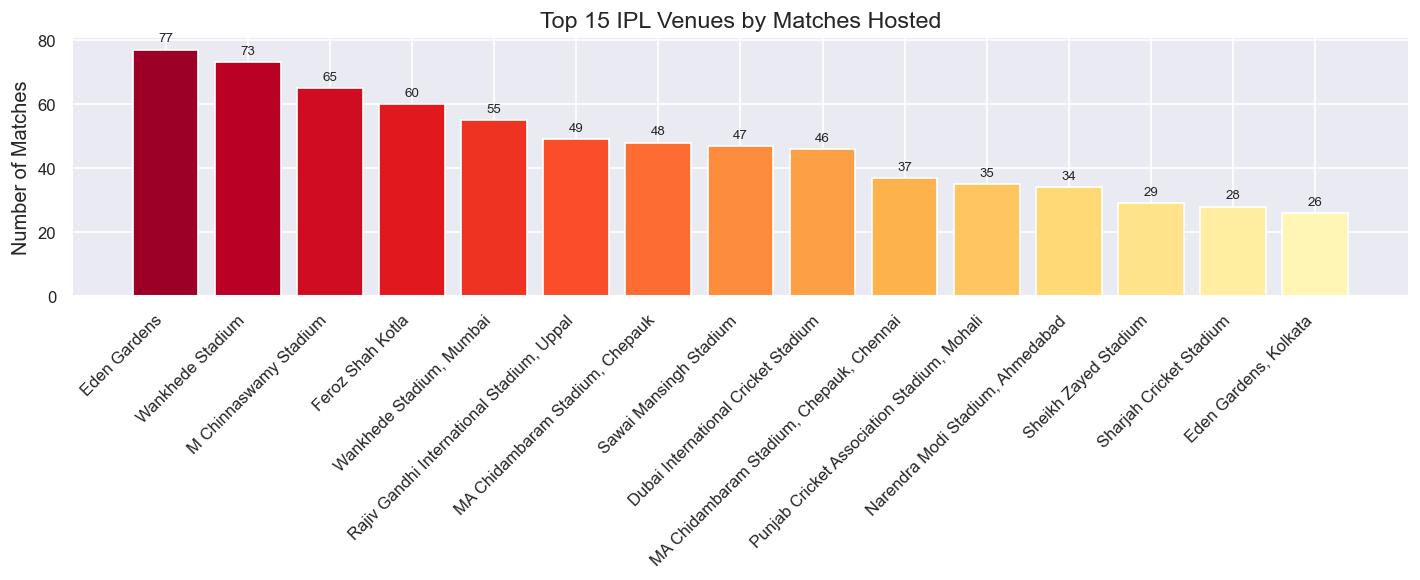

In [7]:
# Expects column: 'venue' or 'city'
venue_col = 'venue' if 'venue' in df.columns else ('city' if 'city' in df.columns else None)

if venue_col:
    # For delivery-level data, get unique matches per venue first
    if 'match_id' in df.columns:
        venue_counts = df.drop_duplicates('match_id')[venue_col].value_counts().head(15)
    else:
        venue_counts = df[venue_col].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(12, 5))
    palette = sns.color_palette('YlOrRd', len(venue_counts))
    bars = ax.bar(venue_counts.index, venue_counts.values, color=palette[::-1])
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
    ax.set_title('Top 15 IPL Venues by Matches Hosted')
    ax.set_ylabel('Number of Matches')
    ax.set_xlabel('')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../data/plot_venues.png', bbox_inches='tight')
    plt.show()
else:
    print('Venue / city column not found.')

## 2.6 Season Trends — Runs & Matches Per Year

TypeError: the dtypes of parameters x (object) and width (float64) are incompatible

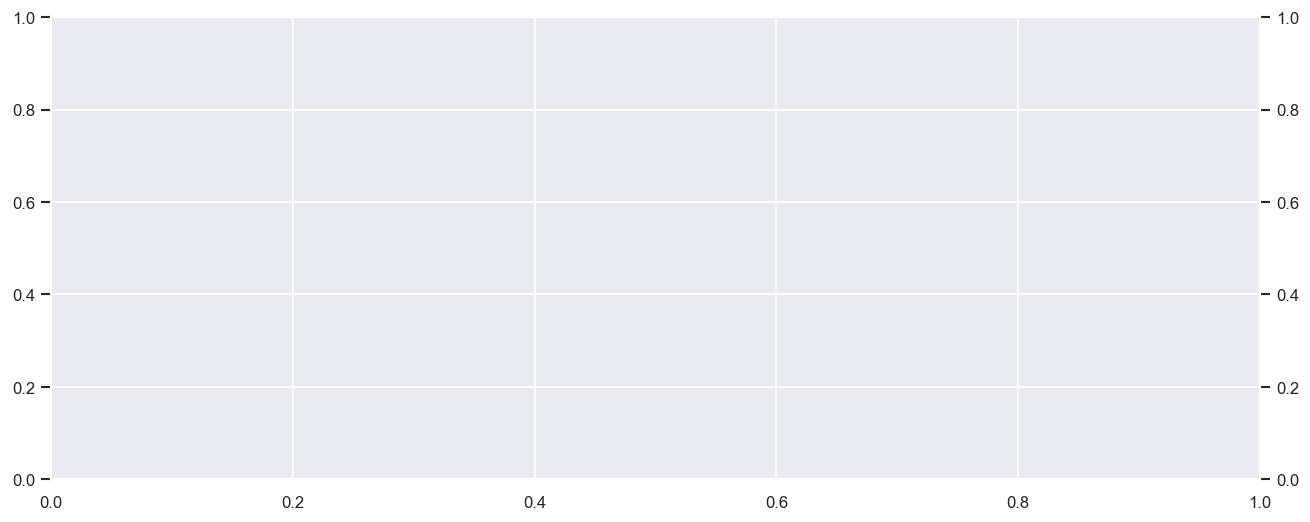

In [8]:
# Expects column: 'season' or a date column to extract year from

if 'season' not in df.columns and 'date' in df.columns:
    df['season'] = pd.to_datetime(df['date'], errors='coerce').dt.year

runs_col = 'batter_runs' if 'batter_runs' in df.columns else (
           'batsman_runs' if 'batsman_runs' in df.columns else None)

if 'season' in df.columns:
    season_stats = df.groupby('season').agg(
        total_runs=(runs_col, 'sum') if runs_col else ('season', 'count'),
        total_balls=('season', 'count')
    ).reset_index() if runs_col else df.groupby('season').size().reset_index(name='total_balls')

    if runs_col:
        season_stats = df.groupby('season').agg(
            total_runs=(runs_col, 'sum'),
            total_balls=('season', 'count')
        ).reset_index()
        season_stats['avg_runs_per_ball'] = (season_stats['total_runs'] / season_stats['total_balls']).round(3)

        fig, ax1 = plt.subplots(figsize=(13, 5))
        ax2 = ax1.twinx()
        ax1.bar(season_stats['season'], season_stats['total_runs'],
                color='#3498db', alpha=0.7, label='Total Runs')
        ax2.plot(season_stats['season'], season_stats['avg_runs_per_ball'],
                 color='#e74c3c', marker='o', linewidth=2, label='Avg Runs/Ball')
        ax1.set_xlabel('Season')
        ax1.set_ylabel('Total Runs', color='#3498db')
        ax2.set_ylabel('Avg Runs per Ball', color='#e74c3c')
        ax1.set_title('IPL Season Trends — Total Runs & Scoring Rate')
        fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
        plt.tight_layout()
        plt.savefig('../data/plot_season_trends.png', bbox_inches='tight')
        plt.show()
    else:
        print('Runs column not found; season column exists.')
        print(df['season'].value_counts().sort_index())
else:
    print('Season or date column not found.')

## 2.7 Correlation Heatmap

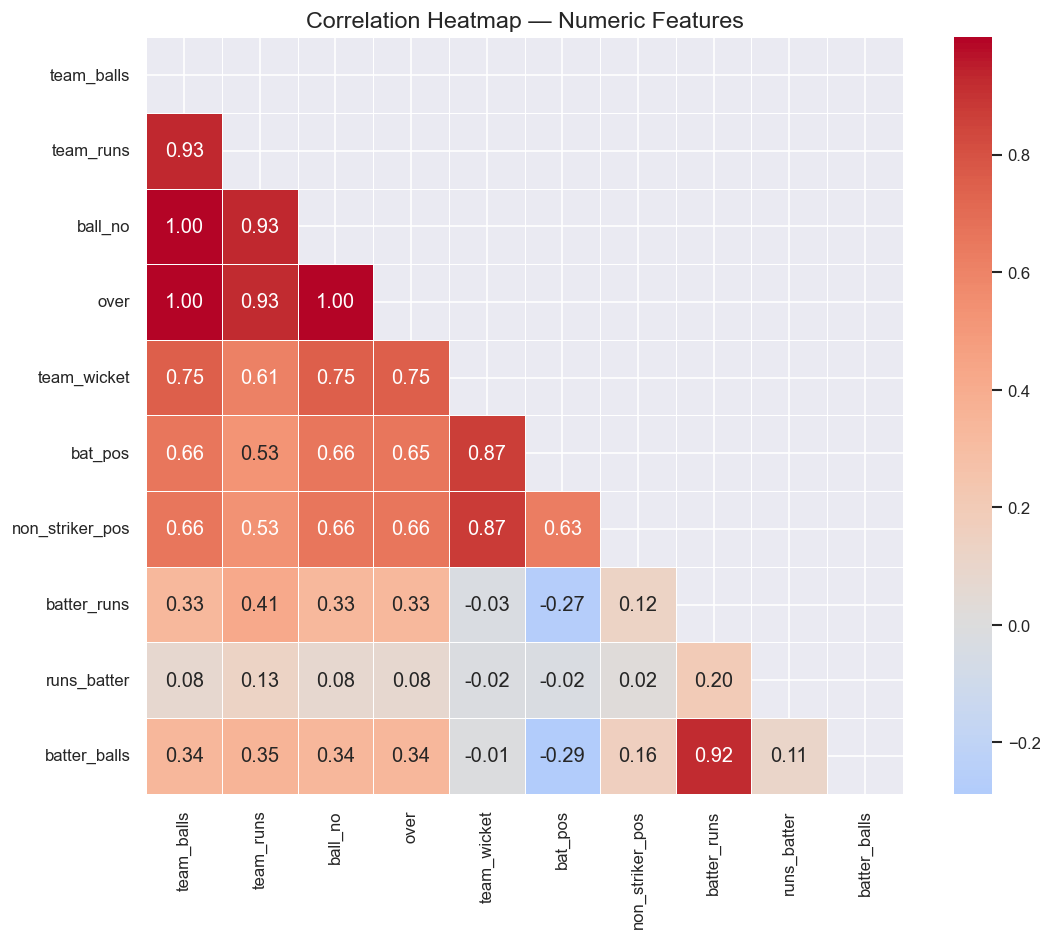

In [9]:
numeric_df = df.select_dtypes(include='number')

if not numeric_df.empty:
    # Drop near-zero variance columns
    numeric_df = numeric_df.loc[:, numeric_df.std() > 0]
    # Keep top 10 most correlated columns for readability
    corr = numeric_df.corr()
    if corr.shape[0] > 10:
        # Pick 10 columns with highest mean abs correlation
        top_cols = corr.abs().mean().nlargest(10).index
        corr = corr.loc[top_cols, top_cols]

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, square=True,
                linewidths=0.5, ax=ax)
    ax.set_title('Correlation Heatmap — Numeric Features')
    plt.tight_layout()
    plt.savefig('../data/plot_corr_heatmap.png', bbox_inches='tight')
    plt.show()
else:
    print('No numeric columns found for heatmap.')

## 2.8 Summary
| Chart | Key Insight |
|-------|------------|
| Win % | Teams with consistent wins across seasons |
| Toss | Toss win ~50–55% correlated with match win |
| Top Scorers | Dominant batters across all seasons |
| Top Wickets | Most reliable bowlers in IPL history |
| Venues | Mumbai, Chennai, Kolkata host most matches |
| Season trends | Average scoring rate increasing year over year |